![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

# CSCK506 Deep Learning: END-MODULE ASSIGNMENT

Pneumonia is an inflammatory condition of the lungs and remains a common and potentially serious disease worldwide. Early and accurate diagnosis is essential for effective treatment, yet traditional methods—such as manual interpretation of chest X-ray images—can be time-consuming and subject to variability among clinicians.

This project explores automated deep learning approaches to detect pneumonia from medical images, with the goal of assisting and improving diagnostic processes.

### Objectives
- Develop models capable of accurately classifying chest X-ray images as NORMAL or PNEUMONIA
- Compare baseline and advanced deep learning approaches
- Evaluate the impact of preprocessing, augmentation, and transfer learning
- Optimize model performance using appropriate metrics (Accuracy, AUC, Precision, Recall, F1-score)


### Project Structure

The project is organized into three main notebooks, each focusing on a key stage of the machine learning pipeline:

1. Exploratory Data Analysis (EDA)
- Understand dataset structure and distribution
- Visualize class imbalance and sample images
- Identify potential challenges (noise, variability, imbalance)

2. Preprocessing & CNN Models

- Data preprocessing and pipeline setup
- Model experimentation with three baselines:

        i. Baseline CNN (no augmentation)
        ii. Baseline CNN with data augmentation
        iii. Tuned CNN (optimized hyperparameters)

The goal is to establish strong reference models and understand the impact of basic improvements.

3. Transfer Learning & Model Comparison
- Use pretrained models VGG16 for feature extraction and fine-tuning
- Improve performance through transfer learning
- Compare all models using standardized evaluation metrics
- Analyze trade-offs between performance and complexity

### Expected Outcomes

By the end of this project, we aim to:

- Identify the most effective modeling approach for pneumonia detection
- Quantify the benefits of augmentation and transfer learning
- Provide a clear comparison of all models

Overall, the goal is to develop a reliable and interpretable diagnostic support tool.

**This notebook is dedicated to Exploratory Data Analysis (EDA).**

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 01 — Chest X-Ray Dataset: Exploratory Data Analysis

Explore the Kermany et al. chest X-ray dataset (~5,856 images, two classes: **NORMAL** vs **PNEUMONIA**) before building any models.  The goals are to understand class balance, image dimensions, colour modes, pixel intensity ranges, and data quality.

**Sections**
1. Environment Setup
2. Configuration
3. Exploratory Data Analysis
   - 3.1 Class Distribution
   - 3.2 Training Set Class Balance
   - 3.3 Image Dimensions
   - 3.4 Colour Mode Check
   - 3.5 Pixel Intensity Distribution
   - 3.6 Corrupted Image Check
   - 3.7 Sample Images
   - 3.8 Raw Image Shapes
4. EDA Summary & Key Findings

### 1. Environment Setup

Import libraries and set random seeds for reproducibility.

In [ ]:
import os
import sys
import json
import random
import pathlib
import importlib.util
import subprocess
import importlib
from datetime import datetime

# Local environments can miss optional tuning deps required by keras-tuner.
for pkg_name in ["tensorboard", "keras-tuner"]:
    if importlib.util.find_spec(pkg_name.replace("-", "_")) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg_name], check=False)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
import keras_tuner as kt
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.19.0
Keras: 3.13.2


### 2. Configuration

Set dataset paths and runtime flags.

In [ ]:
USE_COLAB = True
USE_KAGGLE = False  # Set True when running on Kaggle

In [ ]:
# Configuration
if USE_KAGGLE:

    KAGGLE_HELPERS_PARENT = "/kaggle/input/datasets/omosaad/helpers"
    KAGGLE_HELPERS_DIR = "/kaggle/input/datasets/omosaad/helpers/helpers"

    DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/"
    SAVE_DIR = pathlib.Path("/kaggle/working/saved_models")

    try:
        from helpers import data_utils, model_utils, training_utils, visualization
    except ModuleNotFoundError:
        for p in [KAGGLE_HELPERS_PARENT, KAGGLE_HELPERS_DIR]:
            if os.path.isdir(p) and p not in sys.path:
                sys.path.append(p)
        from helpers import data_utils, model_utils, training_utils, visualization

elif USE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATASET_ROOT = "/content/drive/MyDrive/x-ray-dataset/"
    SAVE_DIR = pathlib.Path("/content/drive/MyDrive/saved_models")

    # Point to the folder containing the 'helpers' folder
    if "/content/drive/MyDrive/Colab Notebooks" not in sys.path:
        sys.path.append("/content/drive/MyDrive/Colab Notebooks")

    from helpers import data_utils, model_utils, training_utils, visualization

    importlib.reload(data_utils)
    importlib.reload(model_utils)
    importlib.reload(training_utils)

else:
    DATASET_ROOT = "dataset"
    SAVE_DIR = pathlib.Path("saved_models")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")  # merged into training pool if present
TEST_DIR = os.path.join(DATASET_ROOT, "test")


for split_path in [TRAIN_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")


runtime_name = "Kaggle" if USE_KAGGLE else ("Google Colab" if USE_COLAB else "Local")
print(f"Environment: {runtime_name}")
print(f"Dataset root: {DATASET_ROOT}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Google Colab
Dataset root: /content/drive/MyDrive/x-ray-dataset/


### 3. Exploratory Data Analysis

Quickly inspect class counts, class balance per split, and a few raw samples before building the training pipeline.

#### 3.1 Class Distribution

Count images per class across all splits.

In [ ]:
split_counts = {
    "train": data_utils.count_images(TRAIN_DIR),
    "test": data_utils.count_images(TEST_DIR),
}
if os.path.isdir(VAL_DIR):
    split_counts["val"] = data_utils.count_images(VAL_DIR)

for split_name, c in split_counts.items():
    print(f"{split_name.upper()}: NORMAL={c['NORMAL']}, PNEUMONIA={c['PNEUMONIA']}, TOTAL={c['NORMAL'] + c['PNEUMONIA']}")

print("Note: original dataset/val images are merged into the training pool for stratified split.")

TRAIN: NORMAL=1341, PNEUMONIA=3875, TOTAL=5216
TEST: NORMAL=234, PNEUMONIA=390, TOTAL=624
VAL: NORMAL=8, PNEUMONIA=8, TOTAL=16
Note: original dataset/val images are merged into the training pool for stratified split.


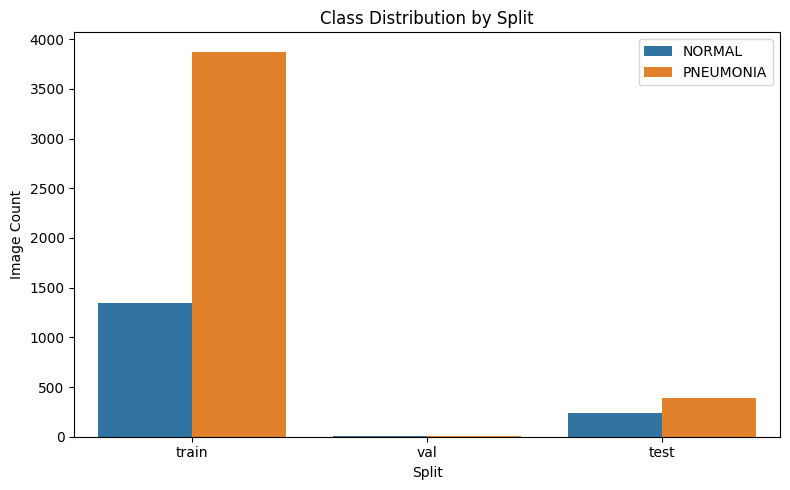

In [ ]:
# Class distribution plot
splits = []
classes = []
counts = []

for split_name in ["train", "val", "test"]:
    for class_name in ["NORMAL", "PNEUMONIA"]:
        splits.append(split_name)
        classes.append(class_name)
        counts.append(split_counts[split_name][class_name])

plt.figure(figsize=(8, 5))
sns.barplot(x=splits, y=counts, hue=classes)
plt.title("Class Distribution by Split")
plt.xlabel("Split")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

#### 3.2 Training Set Class Balance

Visualise the proportion of each class in the training split.

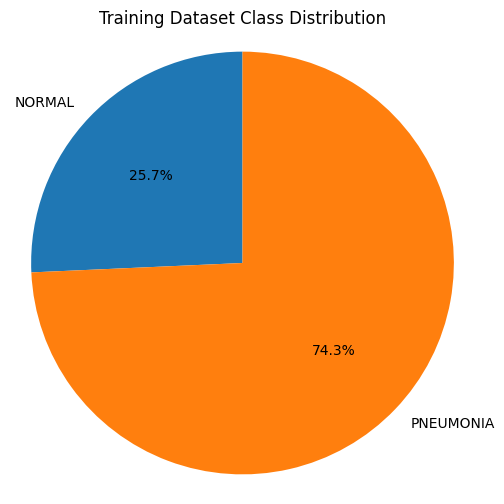

In [ ]:
train_counts = split_counts["train"]

labels = list(train_counts.keys())   # ["NORMAL", "PNEUMONIA"]
sizes = list(train_counts.values()) # corresponding counts

plt.figure(figsize=(6, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Training Dataset Class Distribution")
plt.axis("equal")  # keep it circular
plt.show()

**Observation:**

- **Extremely small validation set:** The original validation folder contains only 16 images.  A new validation split must be reconstructed from the training data.
- **Severe class imbalance in training:** The training dataset has approximately a 3:1 imbalance (NORMAL ≈ 26 %, PNEUMONIA ≈ 74 %).  Class weighting and data augmentation will be used to reduce class bias.

#### 3.3 Image Dimensions

Analyse the distribution of widths and heights across training images.

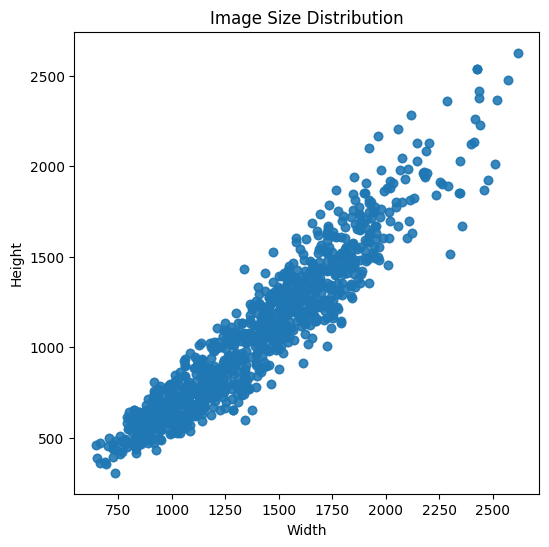

In [ ]:
from PIL import Image

### Image Dimension Analysis

sizes = []

for cls in classes:
    folder = os.path.join(TRAIN_DIR, cls)

    for img_file in os.listdir(folder)[:500]:

        img_path = os.path.join(folder, img_file)
        img = Image.open(img_path)

        sizes.append(img.size)

sizes = np.array(sizes)

# Plot size distribution
plt.figure(figsize=(6,6))

plt.scatter(sizes[:,0], sizes[:,1], alpha=0.5)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.show()

**Observation:** Images appear in multiple resolutions.  All images will be resized to a constant 224 × 224 to ensure uniform input dimensions for the CNN.

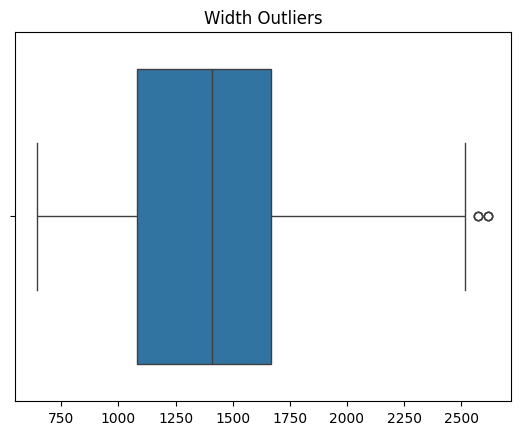

In [ ]:
widths = sizes[:,0]
heights = sizes[:,1]

sns.boxplot(x=widths)
plt.title("Width Outliers")
plt.show()

**Observation:** Images appear in multiple resolutions. Most images fall into roughly ~1100 to ~1700 pixels.
For modelling our CNN, we will resized them into a constant size of 224 x 224 to enhance model performance and training efficiency

#### 3.4 Colour Mode Check

Verify whether images are RGB or grayscale.

In [ ]:
### Check whether images are RGB or grayscale

splits = {
    "train": TRAIN_DIR,
    "val": VAL_DIR,
    "test": TEST_DIR
}

classes = ["NORMAL", "PNEUMONIA"]

for split, path in splits.items():
    for cls in ["NORMAL", "PNEUMONIA"]:
        img_path = os.path.join(path, cls, os.listdir(os.path.join(path, cls))[0])
        img = Image.open(img_path)
        print(split, cls, img.mode)

train NORMAL L
train PNEUMONIA L
val NORMAL L
val PNEUMONIA L
test NORMAL L
test PNEUMONIA L


**Observation:** All images are grayscale.  They will be loaded as 3-channel (RGB) for compatibility with pretrained backbones (e.g. VGG16).

#### 3.5 Pixel Intensity Distribution

Plot histograms of pixel values by split and class to understand the intensity range.

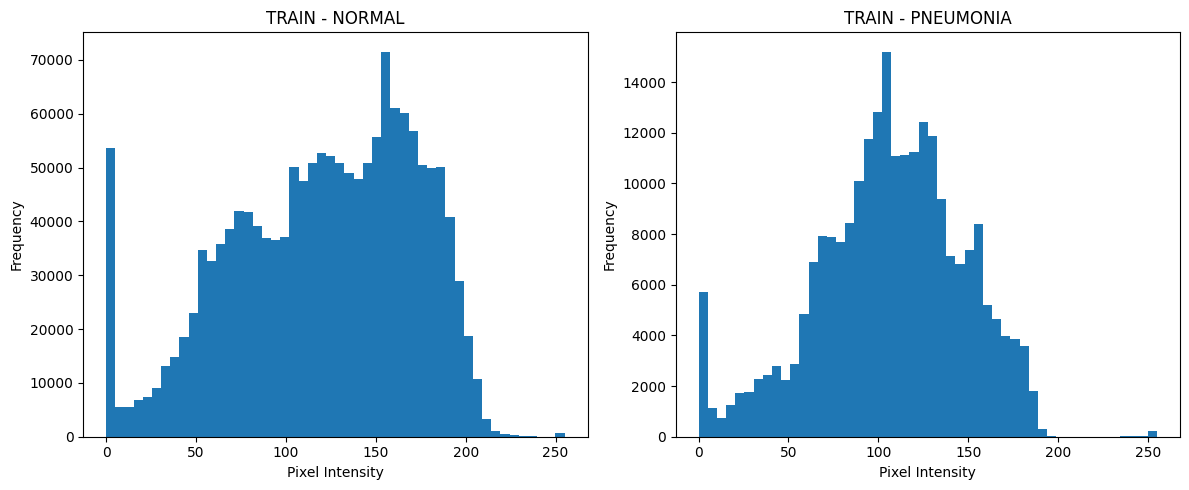

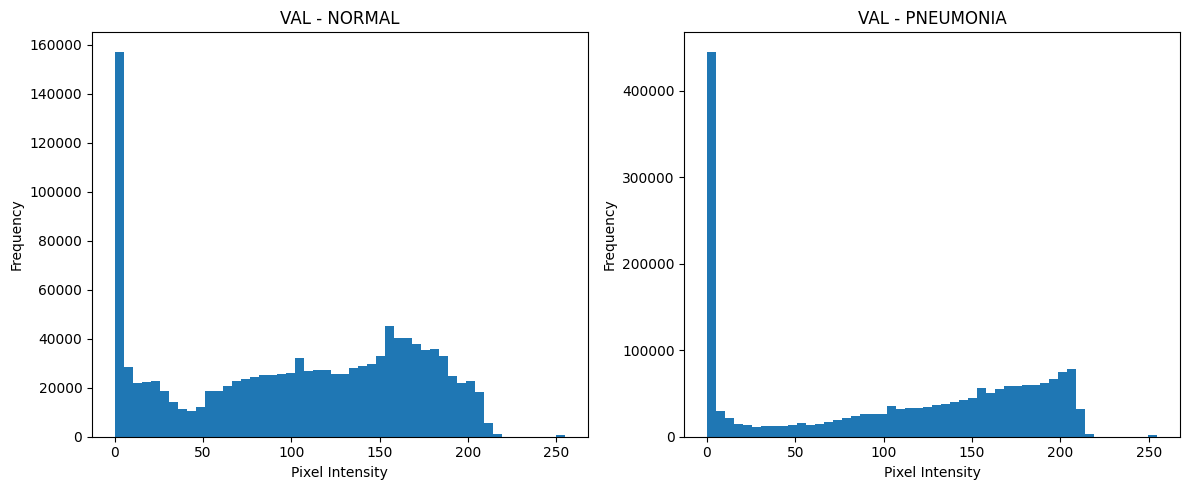

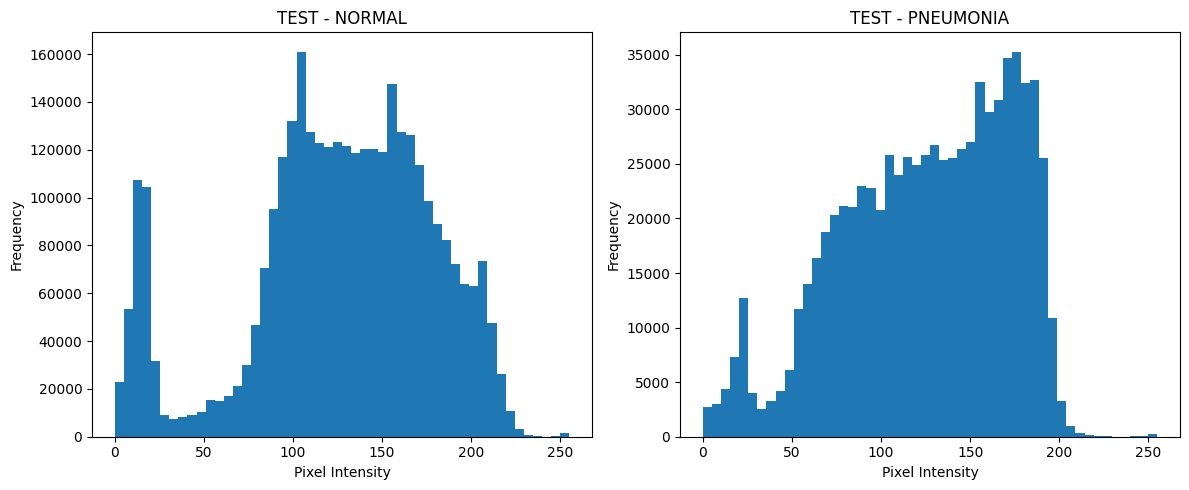

In [ ]:
for split, path in splits.items():
    plt.figure(figsize=(12, 5))  # wider figure for side-by-side plots

    for i, cls in enumerate(["NORMAL", "PNEUMONIA"]):
        # Load first image of each class
        img_path = os.path.join(path, cls, os.listdir(os.path.join(path, cls))[0])
        img = Image.open(img_path)
        img_array = np.array(img)

        # Plot side by side
        plt.subplot(1, 2, i + 1)
        plt.hist(img_array.flatten(), bins=50)
        plt.title(f"{split.upper()} - {cls}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

**Observation:** Pixel values range between 0 and 255.  Values will be normalised to [0, 1] during model preprocessing.

#### 3.6 Corrupted Image Check

Attempt to open every image to detect corruption.

In [ ]:
corrupted = []

for split_name, split_path in splits.items():

    for cls in classes:

        folder = os.path.join(split_path, cls)

        for file in os.listdir(folder):

            path_img = os.path.join(folder, file)

            try:
                img = Image.open(path_img)
                img.verify()

            except:
                corrupted.append(path_img)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


**Observation:** Zero corrupted images detected.  No data cleaning is required.

#### 3.7 Sample Images

Visualise representative NORMAL and PNEUMONIA images from the training set.

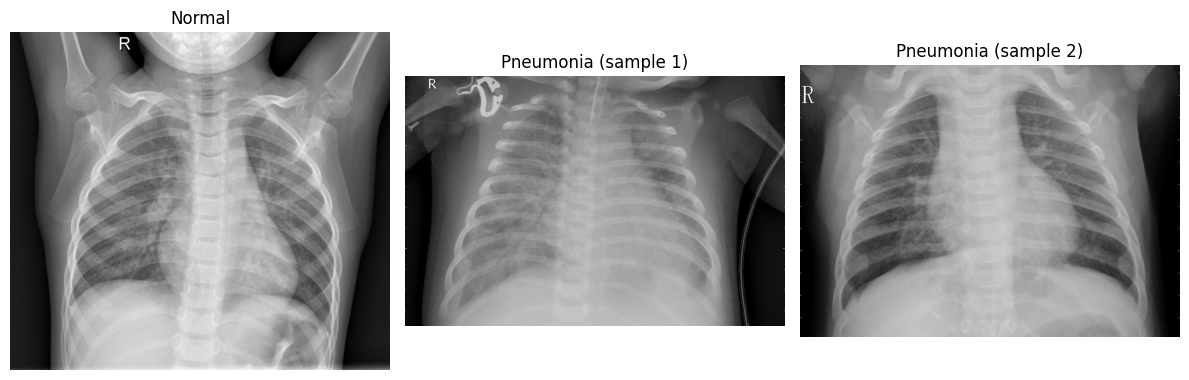

In [ ]:
# Visualize sample images from each class in train split
train_normal_dir = os.path.join(TRAIN_DIR, "NORMAL")
train_pneumonia_dir = os.path.join(TRAIN_DIR, "PNEUMONIA")

valid_image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

normal_samples = sorted(
    f for f in os.listdir(train_normal_dir)
    if f.lower().endswith(valid_image_exts)
)[:3]
pneumonia_samples = sorted(
    f for f in os.listdir(train_pneumonia_dir)
    if f.lower().endswith(valid_image_exts)
)[:3]

sample_paths = [
    os.path.join(train_normal_dir, normal_samples[0]),
    os.path.join(train_pneumonia_dir, pneumonia_samples[0]),
    os.path.join(train_pneumonia_dir, pneumonia_samples[1]),
]

titles = ["Normal", "Pneumonia (sample 1)", "Pneumonia (sample 2)"]

plt.figure(figsize=(12, 4))
for i, (path, title) in enumerate(zip(sample_paths, titles), start=1):
    img = keras.utils.load_img(path, color_mode="grayscale")
    arr = keras.utils.img_to_array(img)
    plt.subplot(1, 3, i)
    plt.imshow(arr.squeeze(), cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

#### 3.8 Raw Image Shapes

Check the native dimensions of a few images before resizing.

In [ ]:
# Check a few raw image shapes (pick first readable image per class)

IMG_SIZE = (224, 224)

valid_image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

shape_samples = []
for class_name, class_dir in [("NORMAL", train_normal_dir), ("PNEUMONIA", train_pneumonia_dir)]:
    candidate_files = sorted(
        f for f in os.listdir(class_dir)
        if f.lower().endswith(valid_image_exts)
    )

    selected = None
    for sample_file in candidate_files:
        sample_path = os.path.join(class_dir, sample_file)
        try:
            img = keras.utils.load_img(sample_path)
            selected = (class_name, sample_file, img.size)
            break
        except Exception:
            continue

    if selected is None:
        print(f"{class_name}: no readable image file found in {class_dir}")
    else:
        shape_samples.append(selected)  # PIL size = (width, height)

for class_name, file_name, size in shape_samples:
    print(f"{class_name}: {file_name} -> original size (W,H) = {size}")
print(f"Target resize: {IMG_SIZE}")

NORMAL: IM-0115-0001.jpeg -> original size (W,H) = (2090, 1858)
PNEUMONIA: person1000_bacteria_2931.jpeg -> original size (W,H) = (1152, 760)
Target resize: (224, 224)


### 4. EDA Summary & Key Findings

| Finding | Detail | Impact on Modelling |
|---------|--------|---------------------|
| **Dataset size** | ~5,856 images (5,232 train + 624 test) | Adequate for CNN training with augmentation |
| **Class imbalance** | ~3:1 PNEUMONIA to NORMAL in training | Use class weighting (`{0: 1.0, 1: 4.0}`) and balanced sampling |
| **Validation set** | Only 16 images in original val split | Reconstruct validation from training data (stratified 90/10 split) |
| **Image dimensions** | Variable resolutions across samples | Resize all images to 224 × 224 |
| **Colour mode** | All images are grayscale | Load as 3-channel (RGB) for compatibility with pretrained models |
| **Pixel range** | 0–255 integer values | Normalise to [0, 1] via `Rescaling(1/255)` layer |
| **Corrupted images** | 0 detected | No data cleaning required |

These findings directly inform the preprocessing pipeline and training strategy used in the modelling notebooks (**02** and **03**).

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)